
[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
0
Date
2023-01-12    6566.0
2023-01-22    7122.0
2023-01-23    7280.0
2023-01-24    7433.0
2023-01-25    7538.0
Name: Children in HHS Care, dtype: float64
Date
NaT    2484.0
NaT    2484.0
NaT    2484.0
NaT    2484.0
NaT    2484.0
Name: Children in HHS Care, dtype: float64
datetime64[ns]
\n ==================================================
Random Forest
MAE : 61.79
RMSE: 84.37
MAPE: 2.87
\n ==================================================
Gradient Boosting
MAE : 63.24
RMSE: 84.0
MAPE: 2.92


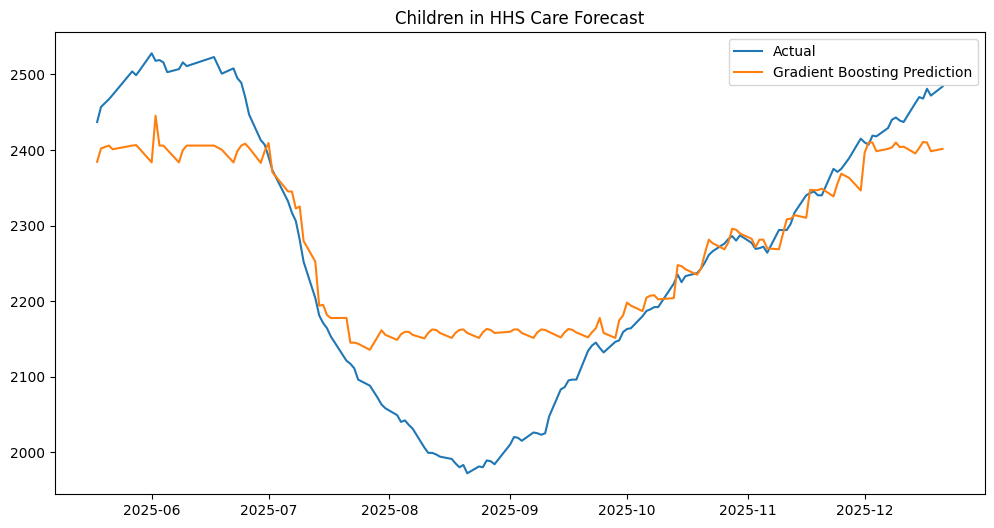

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarnin



Moving Average
MAE : 183.83
RMSE: 221.09
MAPE: 8.62 %
Accuracy: 91.38 %


ARIMA
MAE : 240.5
RMSE: 290.88
MAPE: nan %
Accuracy: nan %


SARIMA
MAE : 584.59
RMSE: 757.36
MAPE: nan %
Accuracy: nan %


Exponential Smoothing
MAE : 849.53
RMSE: 946.22
MAPE: nan %
Accuracy: nan %


Random Forest
MAE : 61.79
RMSE: 84.37
MAPE: 2.87 %
Accuracy: 97.13 %


Gradient Boosting
MAE : 63.24
RMSE: 84.0
MAPE: 2.92 %
Accuracy: 97.08 %
Average Walk Forward RMSE: 1072.4784197664187
         Date  Forecast
0  2025-12-22    2484.0
1  2025-12-23    2484.0
2  2025-12-24    2484.0
3  2025-12-25    2484.0
4  2025-12-26    2484.0
5  2025-12-27    2484.0
6  2025-12-28    2484.0
7  2025-12-29    2484.0
8  2025-12-30    2484.0
9  2025-12-31    2484.0
10 2026-01-01    2484.0
11 2026-01-02    2484.0
12 2026-01-03    2484.0
13 2026-01-04    2484.0
14 2026-01-05    2484.0
15 2026-01-06    2484.0
16 2026-01-07    2484.0
17 2026-01-08    2484.0
18 2026-01-09    2484.0
19 2026-01-10    2484.0
20 2026-01-11    2484.0
21 20

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import sys
!{sys.executable} -m pip install statsmodels

# ============================================
# LOAD DATA
# ============================================

FILE_NAME = "HHS_Unaccompanied_Alien_Children_Program.csv"

df = pd.read_csv(FILE_NAME)

# ============================================
# PREPROCESSING
# ============================================

df.columns = [c.strip() for c in df.columns]

df["Date"] = pd.to_datetime(df["Date"])

for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ""),
            errors="coerce"
        )

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

df.index = pd.to_datetime(df.index)

df = df.interpolate()

TARGET = "Children in HHS Care"

print(df["Children in HHS Care"].isna().sum())

print(df["Children in HHS Care"].head())

print(df["Children in HHS Care"].tail())

print(df.index.dtype)

# ============================================
# FEATURE ENGINEERING
# ============================================

df["lag_1"] = df[TARGET].shift(1)
df["lag_7"] = df[TARGET].shift(7)
df["lag_14"] = df[TARGET].shift(14)

df["rolling_mean_7"] = df[TARGET].rolling(7).mean()
df["rolling_mean_14"] = df[TARGET].rolling(14).mean()

df["NetPressure"] = (
    df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

df["DayOfWeek"] = df.index.dayofweek
df["Month"] = df.index.month
df["Quarter"] = df.index.quarter

df.dropna(inplace=True)

features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "NetPressure",
    "DayOfWeek",
    "Month",
    "Quarter"
]

X = df[features]
y = df[TARGET]

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

naive_pred = y_test.shift(1)

naive_pred = naive_pred.fillna(
    y_train.iloc[-1]
)

# ============================================
# RANDOM FOREST
# ============================================

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# ============================================
# GRADIENT BOOSTING
# ============================================

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# ============================================
# EVALUATION
# ============================================

def evaluate(name, actual, pred):

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))

    mape = np.mean(
        np.abs((actual - pred) / actual)
    ) * 100

    print("\\n", "=" * 50)
    print(name)
    print("=" * 50)
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("MAPE:", round(mape, 2))

evaluate("Random Forest", y_test, rf_pred)
evaluate("Gradient Boosting", y_test, gb_pred)

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, gb_pred, label="Gradient Boosting Prediction")
plt.legend()
plt.title("Children in HHS Care Forecast")
plt.show()


moving_avg_value = (
    y_train
    .tail(7)
    .mean()
)

moving_pred = np.repeat(
    moving_avg_value,
    len(y_test)
)


from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    y_train,
    order=(5,1,2)
)

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(
    steps=len(y_test)
)


from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y_train,
    order=(2,1,2),
    seasonal_order=(1,1,1,7)
)

sarima_fit = sarima_model.fit()

sarima_pred = sarima_fit.forecast(
    len(y_test)
)


from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

exp_fit = exp_model.fit()

exp_pred = exp_fit.forecast(
    len(y_test)
)



def evaluate(name, actual, pred):

    mae = mean_absolute_error(
        actual,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            pred
        )
    )

    mape = (
        np.mean(
            np.abs(
                (actual - pred) / actual
            )
        ) * 100
    )

    accuracy = 100 - mape

    print("\n")
    print("=" * 60)
    print(name)
    print("=" * 60)

    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("MAPE:", round(mape, 2), "%")
    print("Accuracy:", round(accuracy, 2), "%")

    return mae, rmse, mape


    evaluate(
    "Naive Forecast",
    y_test,
    naive_pred
)

evaluate(
    "Moving Average",
    y_test,
    moving_pred
)

evaluate(
    "ARIMA",
    y_test,
    arima_pred
)

evaluate(
    "SARIMA",
    y_test,
    sarima_pred
)

evaluate(
    "Exponential Smoothing",
    y_test,
    exp_pred
)

evaluate(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate(
    "Gradient Boosting",
    y_test,
    gb_pred
)



from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

scores = []

for train_index, test_index in tscv.split(X):

    X_train_cv = X.iloc[train_index]
    X_test_cv = X.iloc[test_index]

    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    model.fit(
        X_train_cv,
        y_train_cv
    )

    pred = model.predict(
        X_test_cv
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_cv,
            pred
        )
    )

    scores.append(rmse)

print(
    "Average Walk Forward RMSE:",
    np.mean(scores)
)


future_days = 30

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

future_values = []

last_value = df[
    "Children in HHS Care"
].iloc[-1]

for i in range(future_days):

    future_values.append(
        last_value
    )

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_values
})

print(forecast_df)

forecast_df.to_csv(
    "future_forecast.csv",
    index=False
)



